# Ancilla + Uncompute Use Case (OpenQASM2 Input)

This notebook compiles two variants of the same ancilla/uncompute model and executes them with Qiskit Aer.

- `opt`: width optimization enabled (`metadata.optimizeWidth = 1`)
- `no_opt`: same model without width optimization

## Workflow

1. Compile both model variants via `POST /debug/compile`.
2. Show width/uncompute differences in generated OpenQASM 3.
3. Demonstrate a Qiskit importer restriction for `if (false) { ... }`.
4. Apply explicit postprocessing for the non-optimized variant and run both circuits in Aer on the same 3-qubit logical output.

In [1]:
import json
import re
from pathlib import Path

import requests
from IPython.display import display
from qiskit import QuantumCircuit, qasm3, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [ ]:
BASE_URL = "http://localhost:8000"
COMPILE_URL = f"{BASE_URL}/debug/compile"

USE_CASE_DIR = Path.cwd()
if not (USE_CASE_DIR / "ancilla_uncompute_qasm2_opt.json").exists():
    USE_CASE_DIR = Path("05-ancilla-qasm2")

MODEL_PATHS = {
    "opt": USE_CASE_DIR / "ancilla_uncompute_qasm2_opt.json",
    "no_opt": USE_CASE_DIR / "ancilla_uncompute_qasm2_no_opt.json",
}
MODEL_PATHS

In [3]:
def compile_model(model_path: Path) -> tuple[dict, str]:
    payload = json.loads(model_path.read_text(encoding="utf-8"))
    response = requests.post(COMPILE_URL, json=payload, timeout=120)
    response.raise_for_status()

    content_type = response.headers.get("content-type", "")
    if "application/json" in content_type:
        raise RuntimeError(f"Unexpected JSON response: {response.json()}")

    return payload, response.text


artifacts: dict[str, dict] = {}
for name, model_path in MODEL_PATHS.items():
    payload, qasm_text = compile_model(model_path)
    artifacts[name] = {"payload": payload, "qasm": qasm_text}
    print(f"{name}: {model_path.name} -> {len(qasm_text.splitlines())} QASM lines")

opt: ancilla_uncompute_qasm2_opt.json -> 29 QASM lines
no_opt: ancilla_uncompute_qasm2_no_opt.json -> 32 QASM lines


In [4]:
def register_width(qasm_text: str) -> int:
    match = re.search(r"^qubit\[(\d+)\]\s+leqo_reg;", qasm_text, flags=re.MULTILINE)
    if not match:
        raise RuntimeError("Could not parse leqo_reg width from generated QASM")
    return int(match.group(1))


for name in ["opt", "no_opt"]:
    qasm_text = artifacts[name]["qasm"]
    width = register_width(qasm_text)
    has_disabled_uncompute = "if (false) {" in qasm_text
    print(f"{name}: width={width}, has_if_false_uncompute={has_disabled_uncompute}")

opt: width=5, has_if_false_uncompute=False
no_opt: width=7, has_if_false_uncompute=True


## Qiskit Restriction and Postprocessing

Qiskit's OpenQASM 3 importer rejects constant-boolean branch conditions like `if (false) { ... }`.

The non-optimized variant intentionally emits this disabled uncompute branch. For simulation only, we strip that disabled block and preserve all removed lines as comments so readers can see exactly what was omitted.

In [4]:
def strip_disabled_uncompute_block_for_qiskit(qasm_text: str) -> str:
    lines = qasm_text.splitlines()
    output: list[str] = []
    i = 0

    while i < len(lines):
        if (
            lines[i].strip() == "@leqo.uncompute"
            and i + 1 < len(lines)
            and lines[i + 1].strip().startswith("if (false)")
        ):
            output.append("// NOTE: Removed disabled uncompute block for Qiskit importer compatibility.")
            output.append("// NOTE: Original LEQO-emitted lines are preserved below as comments.")

            output.append("// " + lines[i])
            output.append("// " + lines[i + 1])
            brace_depth = lines[i + 1].count("{") - lines[i + 1].count("}")
            i += 2

            while i < len(lines) and brace_depth > 0:
                output.append("// " + lines[i])
                brace_depth += lines[i].count("{") - lines[i].count("}")
                i += 1

            continue

        output.append(lines[i])
        i += 1

    return "\n".join(output) + "\n"


no_opt_raw_qasm = artifacts["no_opt"]["qasm"]
try:
    qasm3.loads(no_opt_raw_qasm)
    print("Unexpected: Qiskit imported non-optimized raw QASM directly.")
except Exception as exc:
    print("Expected importer failure for raw non-optimized QASM:")
    print(type(exc).__name__, str(exc))

no_opt_qiskit_qasm = strip_disabled_uncompute_block_for_qiskit(no_opt_raw_qasm)

Expected importer failure for raw non-optimized QASM:
QASM3ImporterError "15,4: conditions must be 'bit == const bool' or 'bitarray == const int', not 'const bool'"


logical output qubits measured: [0, 1, 2]
opt counts (logical outputs only): {'101': 2058, '000': 2038}
no_opt counts (logical outputs only, postprocessed for Qiskit): {'101': 2038, '000': 2058}


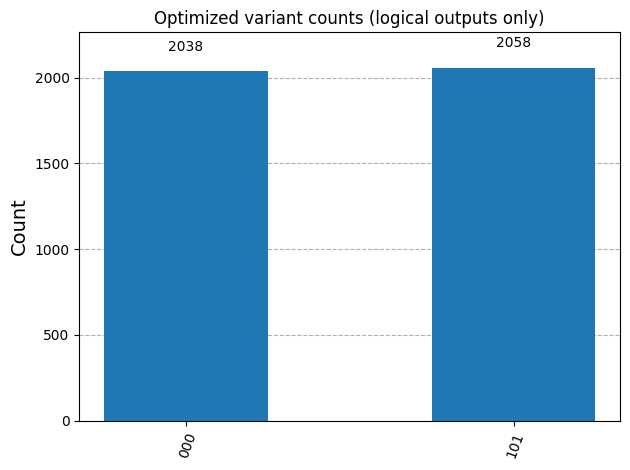

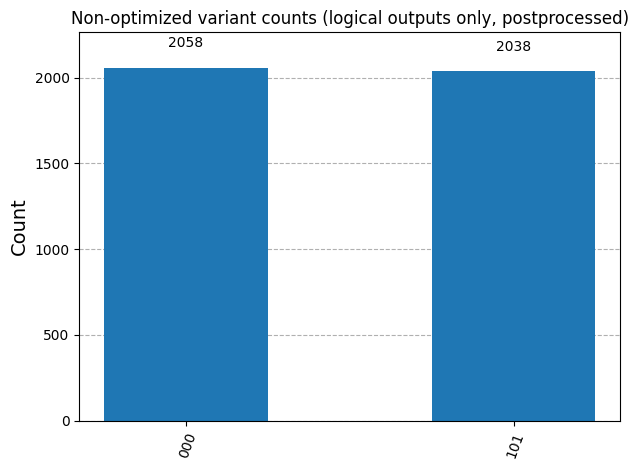

In [5]:
LOGICAL_OUTPUT_QUBITS = [0, 1, 2]
# Measure only logical outputs so optimized and non-optimized states are comparable.


def circuit_from_qasm(qasm_text: str, output_qubits: list[int]) -> QuantumCircuit:
    qc = qasm3.loads(qasm_text)
    measured = QuantumCircuit(qc.num_qubits, len(output_qubits))
    measured.compose(qc, inplace=True)
    for c_idx, q_idx in enumerate(output_qubits):
        measured.measure(q_idx, c_idx)
    return measured


def run_counts(qasm_text: str, output_qubits: list[int], shots: int = 4096) -> dict[str, int]:
    simulator = AerSimulator()
    qc = circuit_from_qasm(qasm_text, output_qubits)
    tqc = transpile(qc, simulator)
    return simulator.run(tqc, shots=shots).result().get_counts()


opt_counts = run_counts(artifacts["opt"]["qasm"], LOGICAL_OUTPUT_QUBITS)
no_opt_counts = run_counts(no_opt_qiskit_qasm, LOGICAL_OUTPUT_QUBITS)

print(f"logical output qubits measured: {LOGICAL_OUTPUT_QUBITS}")
print("opt counts (logical outputs only):", opt_counts)
print("no_opt counts (logical outputs only, postprocessed for Qiskit):", no_opt_counts)
display(plot_histogram(opt_counts, title="Optimized variant counts (logical outputs only)"))
display(plot_histogram(no_opt_counts, title="Non-optimized variant counts (logical outputs only, postprocessed)"))

In [ ]:
print("Postprocessed non-optimized QASM:")
print("\n".join(no_opt_qiskit_qasm.splitlines()[:80]))

Postprocessed non-optimized QASM (first 80 lines):
OPENQASM 3.1;
include "stdgates.inc";
qubit[7] leqo_reg;
/* Start node producer */
let leqo_dce79e3ae9cf57cc8b3752b70005722a_data = leqo_reg[{0, 1, 2}];
h leqo_dce79e3ae9cf57cc8b3752b70005722a_data[0];
cx leqo_dce79e3ae9cf57cc8b3752b70005722a_data[0], leqo_dce79e3ae9cf57cc8b3752b70005722a_data[1];
cx leqo_dce79e3ae9cf57cc8b3752b70005722a_data[1], leqo_dce79e3ae9cf57cc8b3752b70005722a_data[2];
let leqo_dce79e3ae9cf57cc8b3752b70005722a_anc = leqo_reg[{3, 4}];
cx leqo_dce79e3ae9cf57cc8b3752b70005722a_data[0], leqo_dce79e3ae9cf57cc8b3752b70005722a_anc[0];
cx leqo_dce79e3ae9cf57cc8b3752b70005722a_anc[0], leqo_dce79e3ae9cf57cc8b3752b70005722a_anc[1];
@leqo.output 0
let leqo_dce79e3ae9cf57cc8b3752b70005722a_out = leqo_dce79e3ae9cf57cc8b3752b70005722a_data;
// NOTE: Removed disabled uncompute block for Qiskit importer compatibility.
// NOTE: Original LEQO-emitted lines are preserved below as comments.
// @leqo.uncompute
// if (false) {
//   cx

Restriction summary:
- Backend output with `if (false)` is valid for LEQO's internal intent representation.
- Qiskit import requires condition forms other than constant boolean literals.
- The notebook postprocessing is intentionally explicit and local to simulation, so readers can inspect exactly what changed.
- Simulation readout is restricted to the logical output qubits `[0, 1, 2]` for a fair optimized/non-optimized comparison.